# Snapdeal — Customer Purchasing Behavior & Product Recommendation Report

This notebook cleans and analyzes an 800-respondent Snapdeal customer survey to understand
shopping behavior, segment customers, uncover product association patterns, and generate
actionable recommendations.

**Contents**
1. Data Cleaning and Preparation
2. Descriptive Behavior Analysis
3. Customer Segmentation and Profiling
4. Recommendation and Review Insights
5. Market Basket Analysis and Visual Summary
6. Key Takeaways


In [1]:
# Install mlxtend if not already available (used for market basket analysis)
import sys, subprocess
try:
    import mlxtend
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "mlxtend", "--break-system-packages", "-q"])


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
COLORS = ["#E4392E", "#2E86AB", "#F5A623", "#2ECC71", "#8E44AD"]

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)


## 1. Data Cleaning and Preparation

The raw file has 800 rows and 24 columns. We fix column names, standardize categorical
values, handle missing data, and convert rating columns to proper numeric types.


In [3]:
df = pd.read_csv("SnapDeal.csv")
print("Raw shape:", df.shape)
df.head()


Raw shape: (800, 24)


,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,Add_to_Cart_Browsing,Cart_Completion_Frequency,Cart_Abandonment_Factors,Saveforlater_Frequency,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
0,2023/06/07 11:06:40 PM GMT+5:30,59,Others,Once a week,Beauty and Personal Care,Yes,Few times a month,others,Multiple pages,4,Yes,Rarely,others,Always,Yes,Rarely,No,1,Yes,3,3,Customer service,User interface of app,433348
1,2023/06/06 7:08:47 PM GMT+5:30,48,Female,Once a month,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Rarely,categories,Multiple pages,1,Maybe,Often,Changed my mind or no longer need the item,Always,No,Never,Sometimes,1,No,5,2,.,.,735054
2,2023/06/08 9:39:30 PM GMT+5:30,57,Prefer not to say,Multiple times a week,Groceries and Gourmet Food,Sometimes,Rarely,Keyword,First page,2,Yes,Never,Changed my mind or no longer need the item,Sometimes,Yes,Rarely,No,5,Sometimes,3,3,Customer service,Product quality and accuracy,119350
3,2023/06/07 9:22:24 PM GMT+5:30,30,Others,Few times a month,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,others,Multiple pages,2,Maybe,Sometimes,Changed my mind or no longer need the item,Never,Yes,Rarely,Sometimes,4,Sometimes,4,5,Customer service,.,180686
4,2023/06/06 7:21:26 PM GMT+5:30,51,Female,Once a month,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,Filter,First page,5,No,Never,Changed my mind or no longer need the item,Sometimes,Yes,Moderately,Sometimes,1,Yes,3,1,.,I don't have any problem with Amazon,538184


In [4]:
# --- Fix column names: strip whitespace, resolve the duplicate column ---
df.columns = [c.strip() for c in df.columns]

# 'Personalized_Recommendation_Frequency' appears twice after stripping:
# one is the Yes/No/Sometimes survey answer, the other is a 1-5 numeric score
# that was mislabeled with a trailing space in the source file.
cols = list(df.columns)
dup_positions = [i for i, c in enumerate(cols) if c == "Personalized_Recommendation_Frequency"]
cols[dup_positions[1]] = "Recommendation_Frequency_Score"   # the numeric 1-5 field
df.columns = cols

print(df.columns.tolist())


['Timestamp', 'age', 'Gender', 'Purchase_Frequency', 'Purchase_Categories', 'Personalized_Recommendation_Frequency', 'Browsing_Frequency', 'Product_Search_Method', 'Search_Result_Exploration', 'Customer_Reviews_Importance', 'Add_to_Cart_Browsing', 'Cart_Completion_Frequency', 'Cart_Abandonment_Factors', 'Saveforlater_Frequency', 'Review_Left', 'Review_Reliability', 'Review_Helpfulness', 'Recommendation_Frequency_Score', 'Recommendation_Helpfulness', 'Rating_Accuracy', 'Shopping_Satisfaction', 'Service_Appreciation', 'Improvement_Areas', 'transaction']


In [5]:
# --- Remove duplicate rows / duplicate transaction records ---
before = len(df)
df = df.drop_duplicates()
df = df.drop_duplicates(subset="transaction", keep="first")
print(f"Removed {before - len(df)} duplicate rows. Shape now: {df.shape}")


Removed 0 duplicate rows. Shape now: (800, 24)


In [6]:
# --- Clean the Timestamp column ---
df["Timestamp"] = df["Timestamp"].astype(str).str.replace(r"\s*GMT.*$", "", regex=True)
df["Timestamp"] = pd.to_datetime(df["Timestamp"], format="%Y/%m/%d %I:%M:%S %p", errors="coerce")


In [7]:
# --- Strip whitespace from every text column and treat '.' as missing ---
text_cols = df.select_dtypes(include="object").columns
for c in text_cols:
    df[c] = df[c].astype(str).str.strip()
    df[c] = df[c].replace({".": np.nan, "": np.nan, "nan": np.nan})

print("Missing values per column (before filling):")
print(df.isna().sum()[df.isna().sum() > 0])


Missing values per column (before filling):
Product_Search_Method    149
Service_Appreciation      89
Improvement_Areas         38
dtype: int64


/tmp/ipykernel_640/2709440636.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include="object").columns


In [8]:
# --- Standardize categorical labels ---
df["Gender"] = df["Gender"].replace({"Others": "Other"})

df["Product_Search_Method"] = df["Product_Search_Method"].replace({
    "others": "Other", "categories": "Category Browsing",
    "Keyword": "Keyword Search", "Filter": "Filter"
})
df["Product_Search_Method"] = df["Product_Search_Method"].fillna("Not specified")

df["Cart_Abandonment_Factors"] = df["Cart_Abandonment_Factors"].replace({"others": "Other"})

df["Service_Appreciation"] = df["Service_Appreciation"].fillna("Not specified")
df["Improvement_Areas"] = df["Improvement_Areas"].fillna("Not specified")


In [9]:
# --- Convert rating columns to numeric types ---
numeric_cols = ["age", "Customer_Reviews_Importance", "Recommendation_Frequency_Score",
                "Rating_Accuracy", "Shopping_Satisfaction"]
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print("Remaining missing values (all columns):", df.isna().sum().sum() - df["Timestamp"].isna().sum())


Remaining missing values (all columns): 0


In [10]:
# --- Split multi-select Purchase_Categories into a list, for market basket analysis ---
def split_categories(x):
    parts = [p.strip() for p in str(x).split(";") if p.strip()]
    return ["Other" if p.lower() == "others" else p for p in parts]

df["Purchase_Categories_List"] = df["Purchase_Categories"].apply(split_categories)

print("Cleaned dataset shape:", df.shape)
df.to_csv("SnapDeal_cleaned.csv", index=False)
df.head()


Cleaned dataset shape: (800, 25)


,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,Add_to_Cart_Browsing,Cart_Completion_Frequency,Cart_Abandonment_Factors,Saveforlater_Frequency,Review_Left,Review_Reliability,Review_Helpfulness,Recommendation_Frequency_Score,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction,Purchase_Categories_List
0,2023-06-07 23:06:40,59,Other,Once a week,Beauty and Personal Care,Yes,Few times a month,Other,Multiple pages,4,Yes,Rarely,Other,Always,Yes,Rarely,No,1,Yes,3,3,Customer service,User interface of app,433348,[Beauty and Personal Care]
1,2023-06-06 19:08:47,48,Female,Once a month,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Rarely,Category Browsing,Multiple pages,1,Maybe,Often,Changed my mind or no longer need the item,Always,No,Never,Sometimes,1,No,5,2,Not specified,Not specified,735054,"[Beauty and Personal Care, Clothing and Fashio..."
2,2023-06-08 21:39:30,57,Prefer not to say,Multiple times a week,Groceries and Gourmet Food,Sometimes,Rarely,Keyword Search,First page,2,Yes,Never,Changed my mind or no longer need the item,Sometimes,Yes,Rarely,No,5,Sometimes,3,3,Customer service,Product quality and accuracy,119350,[Groceries and Gourmet Food]
3,2023-06-07 21:22:24,30,Other,Few times a month,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,Other,Multiple pages,2,Maybe,Sometimes,Changed my mind or no longer need the item,Never,Yes,Rarely,Sometimes,4,Sometimes,4,5,Customer service,Not specified,180686,"[Groceries and Gourmet Food, Beauty and Person..."
4,2023-06-06 19:21:26,51,Female,Once a month,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,Filter,First page,5,No,Never,Changed my mind or no longer need the item,Sometimes,Yes,Moderately,Sometimes,1,Yes,3,1,Not specified,I don't have any problem with Amazon,538184,"[Groceries and Gourmet Food, Beauty and Person..."


## 2. Descriptive Behavior Analysis

Summarizing demographics, purchase habits, browsing methods, cart abandonment,
and the four core rating metrics.


In [11]:
print("Age: mean = {:.1f}, median = {:.0f}, range = {}-{}".format(
    df["age"].mean(), df["age"].median(), df["age"].min(), df["age"].max()))
print()
print("Gender distribution:")
print(df["Gender"].value_counts())


Age: mean = 36.1, median = 37, range = 3-67

Gender distribution:
Gender
Male                 213
Female               201
Prefer not to say    194
Other                192
Name: count, dtype: int64


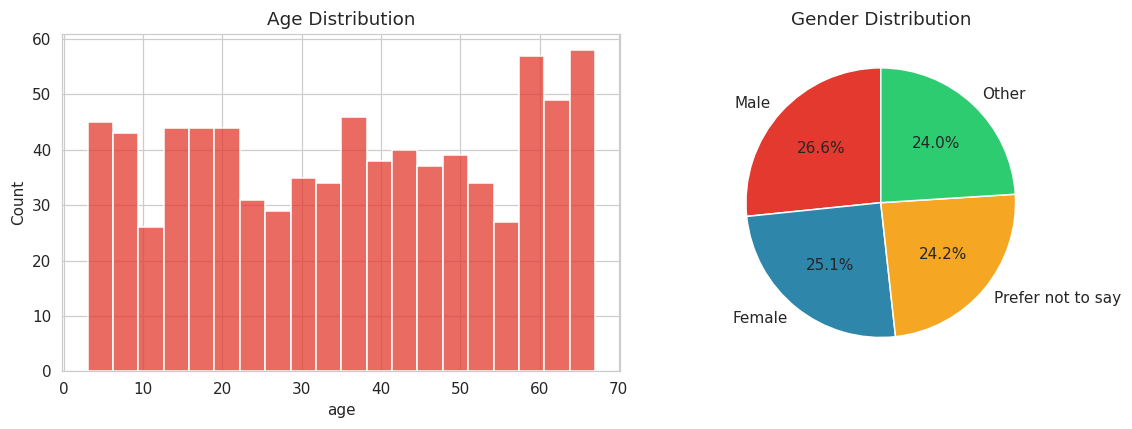

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df["age"], bins=20, color=COLORS[0], ax=axes[0])
axes[0].set_title("Age Distribution")

gender_counts = df["Gender"].value_counts()
axes[1].pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%",
            colors=COLORS, startangle=90, wedgeprops={"edgecolor": "white"})
axes[1].set_title("Gender Distribution")
plt.tight_layout()
plt.show()


In [13]:
print("Purchase frequency:")
print(df["Purchase_Frequency"].value_counts())
print()

category_counts = Counter()
for lst in df["Purchase_Categories_List"]:
    category_counts.update(lst)
category_counts = pd.Series(category_counts).sort_values(ascending=False)
print("Most popular product categories:")
print(category_counts)


Purchase frequency:
Purchase_Frequency
Multiple times a week     166
Once a month              164
Once a week               161
Few times a month         157
Less than once a month    152
Name: count, dtype: int64

Most popular product categories:
Clothing and Fashion          476
Beauty and Personal Care      414
Home and Kitchen              405
Other                         396
Groceries and Gourmet Food    381
dtype: int64


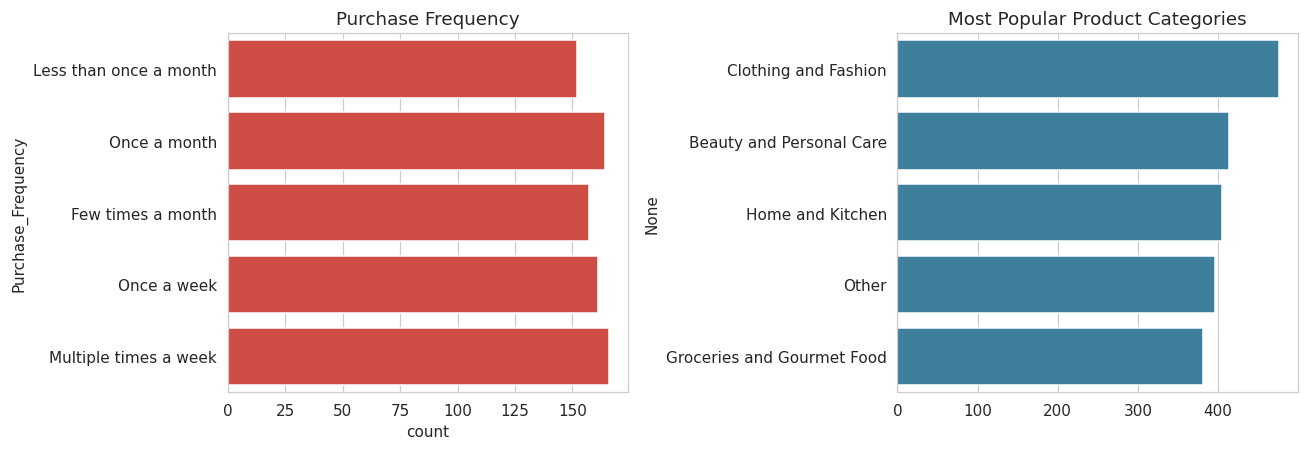

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
order = ["Less than once a month", "Once a month", "Few times a month", "Once a week", "Multiple times a week"]
sns.countplot(data=df, y="Purchase_Frequency", order=order, color=COLORS[0], ax=axes[0])
axes[0].set_title("Purchase Frequency")

sns.barplot(x=category_counts.values, y=category_counts.index, color=COLORS[1], ax=axes[1])
axes[1].set_title("Most Popular Product Categories")
plt.tight_layout()
plt.show()


In [15]:
print("Top product search / browsing methods:")
print(df["Product_Search_Method"].value_counts())
print()
print("Cart abandonment factors:")
print(df["Cart_Abandonment_Factors"].value_counts())


Top product search / browsing methods:
Product_Search_Method
Other                182
Keyword Search       163
Category Browsing    156
Filter               150
Not specified        149
Name: count, dtype: int64

Cart abandonment factors:
Cart_Abandonment_Factors
Found a better price elsewhere                219
Other                                         196
High shipping costs                           194
Changed my mind or no longer need the item    191
Name: count, dtype: int64


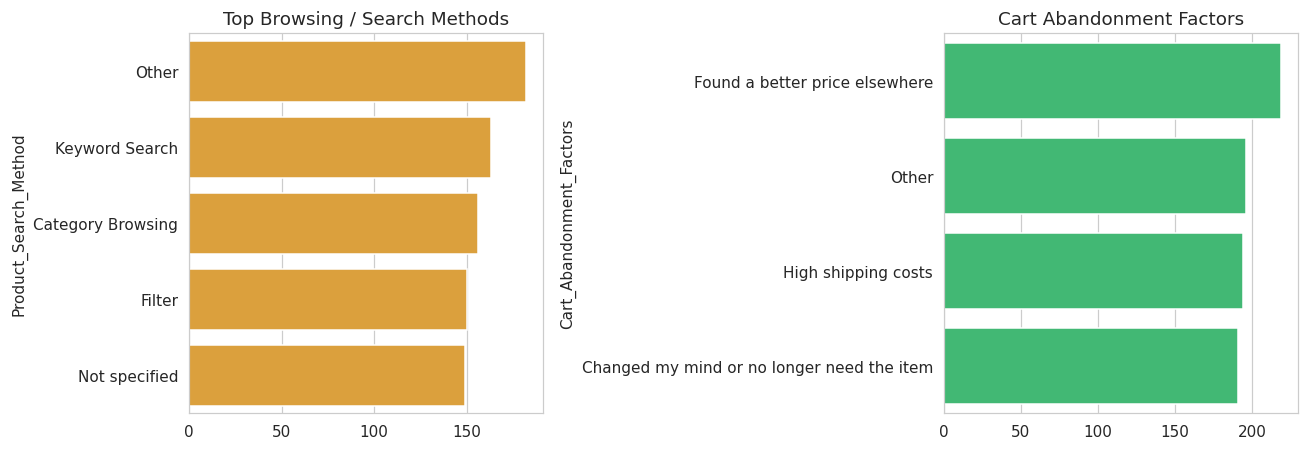

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
sns.barplot(x=df["Product_Search_Method"].value_counts().values,
            y=df["Product_Search_Method"].value_counts().index, color=COLORS[2], ax=axes[0])
axes[0].set_title("Top Browsing / Search Methods")

sns.barplot(x=df["Cart_Abandonment_Factors"].value_counts().values,
            y=df["Cart_Abandonment_Factors"].value_counts().index, color=COLORS[3], ax=axes[1])
axes[1].set_title("Cart Abandonment Factors")
plt.tight_layout()
plt.show()


In [17]:
rating_cols = ["Shopping_Satisfaction", "Rating_Accuracy", "Customer_Reviews_Importance",
               "Recommendation_Frequency_Score"]
summary_stats = df[rating_cols].agg(["mean", "median", "std"]).T.round(2)
print("Summary statistics for key rating metrics (scale 1-5):")
summary_stats


Summary statistics for key rating metrics (scale 1-5):


,mean,median,std
Shopping_Satisfaction,2.99,3.0,1.41
Rating_Accuracy,2.96,3.0,1.43
Customer_Reviews_Importance,2.99,3.0,1.40
Recommendation_Frequency_Score,2.91,3.0,1.41


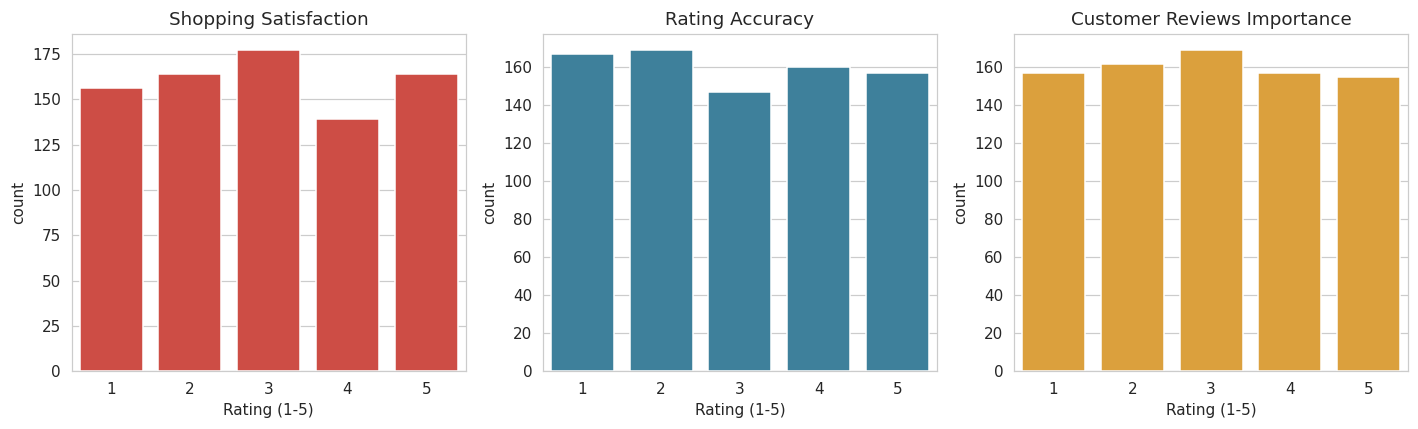

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, color in zip(axes, rating_cols[:3], COLORS[:3]):
    sns.countplot(data=df, x=col, color=color, ax=ax)
    ax.set_title(col.replace("_", " "))
    ax.set_xlabel("Rating (1-5)")
plt.tight_layout()
plt.show()


## 3. Customer Segmentation and Profiling

We build two complementary views:
- **Rule-based profiles**, following the business definitions in the brief.
- **K-Means clustering**, a data-driven grouping based on 12 behavioral survey responses.


In [19]:
# --- Helper scores used for segmentation ---
freq_order = {"Multiple times a week": 5, "Once a week": 4, "Few times a month": 3,
              "Once a month": 2, "Less than once a month": 1}
df["Purchase_Frequency_Score"] = df["Purchase_Frequency"].map(freq_order)

cart_map = {"Never": 0, "Rarely": 1, "Sometimes": 2, "Often": 3, "Always": 4}
df["Cart_Completion_Score"] = df["Cart_Completion_Frequency"].map(cart_map)
df["Saveforlater_Score"] = df["Saveforlater_Frequency"].map(cart_map)

browse_order = {"Rarely": 2, "Few times a month": 3, "Few times a week": 4, "Multiple times a day": 5}
df["Browsing_Frequency_Score"] = df["Browsing_Frequency"].map(browse_order)

yn_map = {"Yes": 1, "Sometimes": 0.5, "No": 0}
df["Personalized_Rec_Freq_Score"] = df["Personalized_Recommendation_Frequency"].map(yn_map)
df["Recommendation_Helpfulness_Score"] = df["Recommendation_Helpfulness"].map(yn_map)
df["Review_Helpfulness_Score"] = df["Review_Helpfulness"].map(yn_map)

reliability_map = {"Never": 0, "Rarely": 1, "Occasionally": 2, "Moderately": 3, "Heavily": 4}
df["Review_Reliability_Score"] = df["Review_Reliability"].map(reliability_map)


In [20]:
# --- Rule-based profiles (as defined in the brief) ---
def assign_profile(row):
    if row["Purchase_Frequency_Score"] >= 4 and row["Shopping_Satisfaction"] >= 4:
        return "Frequent Buyer"
    if row["Shopping_Satisfaction"] <= 2 or row["Cart_Completion_Score"] <= 1:
        return "At-Risk Customer"
    return "Occasional Shopper"

df["Segment"] = df.apply(assign_profile, axis=1)

print(df["Segment"].value_counts())
print()
profile_summary = df.groupby("Segment").agg(
    customers=("transaction", "count"),
    avg_age=("age", "mean"),
    avg_satisfaction=("Shopping_Satisfaction", "mean"),
    avg_purchase_freq_score=("Purchase_Frequency_Score", "mean"),
    pct_female=("Gender", lambda s: (s == "Female").mean() * 100),
).round(2)
profile_summary


Segment
At-Risk Customer      448
Occasional Shopper    224
Frequent Buyer        128
Name: count, dtype: int64



,customers,avg_age,avg_satisfaction,avg_purchase_freq_score,pct_female
Segment,,,,,
At-Risk Customer,448,35.93,2.12,2.93,25.45
Frequent Buyer,128,35.98,4.56,4.48,21.09
Occasional Shopper,224,36.34,3.82,2.41,26.79


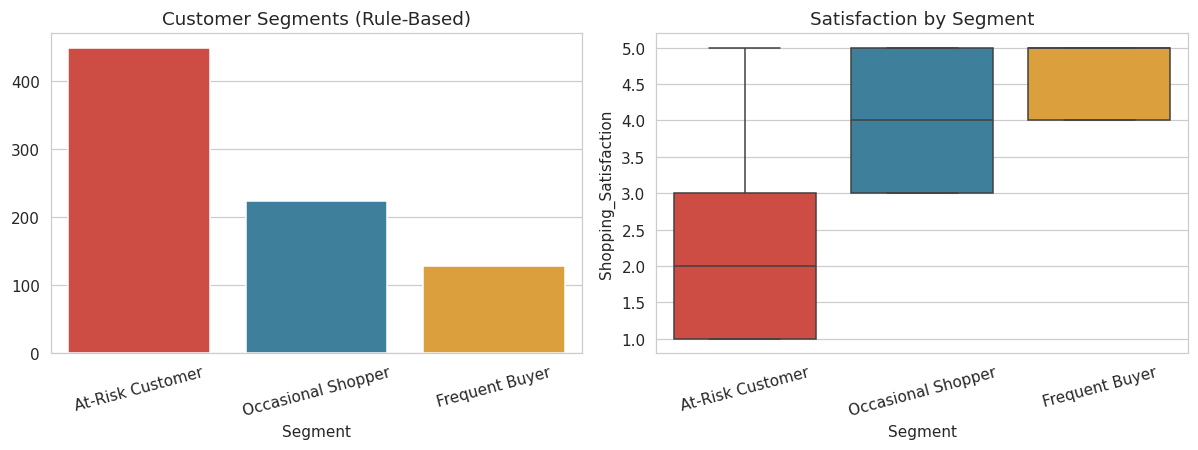

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
seg_counts = df["Segment"].value_counts()
sns.barplot(x=seg_counts.index, y=seg_counts.values, hue=seg_counts.index,
            palette=COLORS[:3], legend=False, ax=axes[0])
axes[0].set_title("Customer Segments (Rule-Based)")
axes[0].tick_params(axis="x", rotation=15)

sns.boxplot(data=df, x="Segment", y="Shopping_Satisfaction", hue="Segment",
            palette=COLORS[:3], legend=False, ax=axes[1])
axes[1].set_title("Satisfaction by Segment")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()


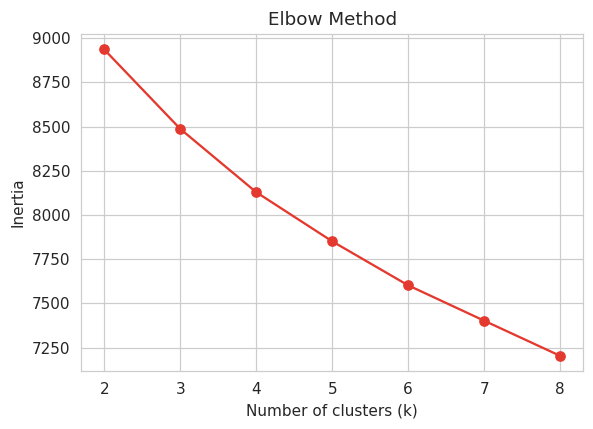

In [22]:
# --- K-Means clustering on behavioral features ---
feature_cols = ["Purchase_Frequency_Score", "Browsing_Frequency_Score", "Customer_Reviews_Importance",
                "Cart_Completion_Score", "Saveforlater_Score", "Personalized_Rec_Freq_Score",
                "Recommendation_Frequency_Score", "Recommendation_Helpfulness_Score",
                "Review_Reliability_Score", "Review_Helpfulness_Score", "Rating_Accuracy",
                "Shopping_Satisfaction"]

X = df[feature_cols].fillna(df[feature_cols].mean())
X_scaled = StandardScaler().fit_transform(X)

# Elbow method to choose k
inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled).inertia_ for k in range(2, 9)]
plt.figure(figsize=(5.5, 4))
plt.plot(range(2, 9), inertias, marker="o", color=COLORS[0])
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.tight_layout()
plt.show()


In [23]:
K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

cluster_profile = df.groupby("Cluster")[feature_cols].mean().round(2)
cluster_profile["customers"] = df["Cluster"].value_counts().sort_index()
cluster_profile


,Purchase_Frequency_Score,Browsing_Frequency_Score,Customer_Reviews_Importance,Cart_Completion_Score,Saveforlater_Score,Personalized_Rec_Freq_Score,Recommendation_Frequency_Score,Recommendation_Helpfulness_Score,Review_Reliability_Score,Review_Helpfulness_Score,Rating_Accuracy,Shopping_Satisfaction,customers
Cluster,,,,,,,,,,,,,
0,2.54,2.86,2.49,1.20,2.63,0.64,3.19,0.48,1.16,0.58,3.23,2.82,207
1,3.38,4.00,3.64,1.57,2.19,0.67,2.39,0.59,3.04,0.46,2.63,3.41,209
2,2.08,3.56,3.68,2.74,1.44,0.24,3.53,0.29,2.18,0.36,3.02,3.29,188
3,4.09,3.65,2.16,2.82,1.65,0.31,2.58,0.54,1.63,0.56,2.99,2.43,196


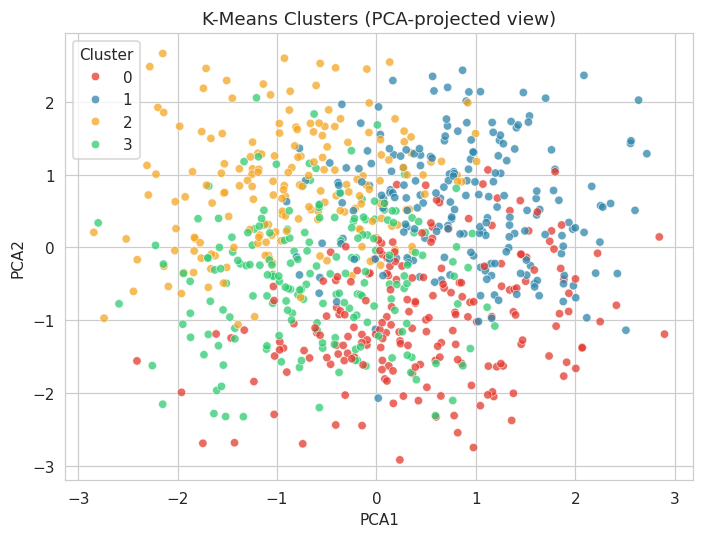

In [24]:
# 2D view of the clusters via PCA
coords = PCA(n_components=2, random_state=42).fit_transform(X_scaled)
df["PCA1"], df["PCA2"] = coords[:, 0], coords[:, 1]

plt.figure(figsize=(6.5, 5))
sns.scatterplot(data=df, x="PCA1", y="PCA2", hue="Cluster", palette=COLORS[:K], s=30, alpha=0.75)
plt.title("K-Means Clusters (PCA-projected view)")
plt.tight_layout()
plt.show()


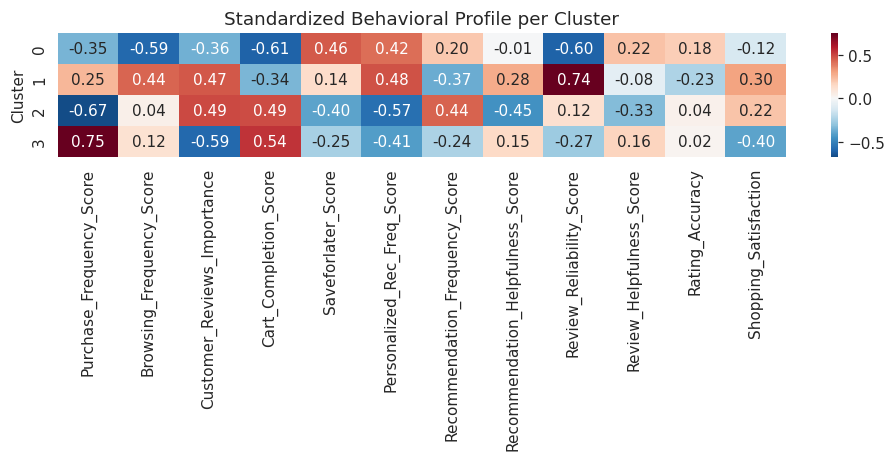

In [25]:
# Standardized heatmap to interpret what makes each cluster distinct
z = pd.DataFrame(X_scaled, columns=feature_cols)
z["Cluster"] = df["Cluster"].values
plt.figure(figsize=(9, 4.3))
sns.heatmap(z.groupby("Cluster").mean(), annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Standardized Behavioral Profile per Cluster")
plt.tight_layout()
plt.show()


**Reading the clusters:** Cluster 0 saves items but rarely completes carts and doesn't
trust reviews yet responds to personalization. Cluster 1 has the highest satisfaction and
highest review trust — the best-engaged group. Cluster 2 buys least often and engages least
with recommendations. Cluster 3 buys most often but has the lowest satisfaction — a
high-frequency-but-unhappy group worth prioritizing, since they represent the most revenue
at risk.

## 4. Recommendation and Review Insights

Examining whether recommendation helpfulness and review trust actually move the needle
on shopping satisfaction and rating accuracy.


In [26]:
reco_sat = df.groupby("Recommendation_Helpfulness")["Shopping_Satisfaction"].mean().reindex(["No", "Sometimes", "Yes"])
review_rating = df.groupby("Review_Reliability")["Rating_Accuracy"].mean().reindex(
    ["Never", "Rarely", "Occasionally", "Moderately", "Heavily"])

print("Avg Shopping Satisfaction by Recommendation Helpfulness:")
print(reco_sat.round(2))
print()
print("Avg Rating Accuracy by Review Reliability (trust level):")
print(review_rating.round(2))


Avg Shopping Satisfaction by Recommendation Helpfulness:
Recommendation_Helpfulness
No           2.89
Sometimes    3.08
Yes          3.02
Name: Shopping_Satisfaction, dtype: float64

Avg Rating Accuracy by Review Reliability (trust level):
Review_Reliability
Never           3.04
Rarely          2.97
Occasionally    2.85
Moderately      2.98
Heavily         2.99
Name: Rating_Accuracy, dtype: float64


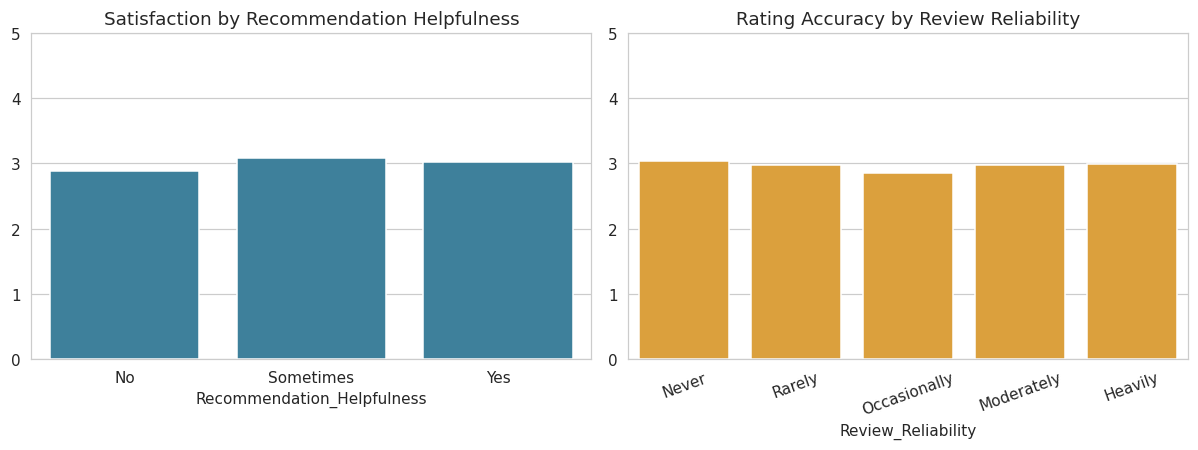

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
sns.barplot(x=reco_sat.index, y=reco_sat.values, color=COLORS[1], ax=axes[0])
axes[0].set_title("Satisfaction by Recommendation Helpfulness")
axes[0].set_ylim(0, 5)

sns.barplot(x=review_rating.index, y=review_rating.values, color=COLORS[2], ax=axes[1])
axes[1].set_title("Rating Accuracy by Review Reliability")
axes[1].tick_params(axis="x", rotation=20)
axes[1].set_ylim(0, 5)
plt.tight_layout()
plt.show()


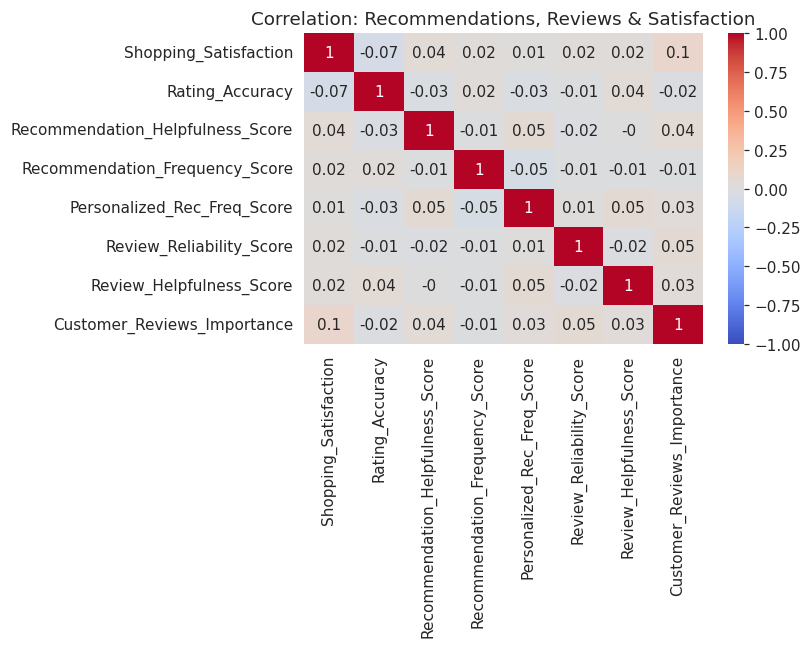

In [28]:
corr_cols = ["Shopping_Satisfaction", "Rating_Accuracy", "Recommendation_Helpfulness_Score",
             "Recommendation_Frequency_Score", "Personalized_Rec_Freq_Score",
             "Review_Reliability_Score", "Review_Helpfulness_Score", "Customer_Reviews_Importance"]
corr_matrix = df[corr_cols].corr().round(2)

plt.figure(figsize=(7.5, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation: Recommendations, Reviews & Satisfaction")
plt.tight_layout()
plt.show()


In [29]:
pers_engagement = df["Personalized_Recommendation_Frequency"].value_counts(normalize=True).reindex(
    ["No", "Sometimes", "Yes"]) * 100
print("Personalized recommendation engagement (% of customers):")
print(pers_engagement.round(1))


Personalized recommendation engagement (% of customers):
Personalized_Recommendation_Frequency
No           35.6
Sometimes    34.0
Yes          30.4
Name: proportion, dtype: float64


**Insight:** Correlations between recommendation helpfulness, review trust, and
satisfaction/rating accuracy are all weak (roughly -0.07 to +0.10) — the current
recommendation and review systems have little measurable influence on customer happiness.
Only ~30% of customers find personalized recommendations consistently helpful. This points to
an opportunity to rebuild recommendations around actual co-purchase behavior (see Section 5)
rather than generic popularity signals.

## 5. Market Basket Analysis and Visual Summary

Using the Apriori algorithm on the multi-select `Purchase_Categories` field to find which
product categories are bought together, informing cross-sell and inventory decisions.


In [30]:
transactions = df["Purchase_Categories_List"].tolist()
encoder = TransactionEncoder()
basket_df = pd.DataFrame(encoder.fit(transactions).transform(transactions), columns=encoder.columns_)

frequent_itemsets = apriori(basket_df, min_support=0.05, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
rules["antecedents_str"] = rules["antecedents"].apply(lambda x: ", ".join(sorted(x)))
rules["consequents_str"] = rules["consequents"].apply(lambda x: ", ".join(sorted(x)))
rules = rules.sort_values("lift", ascending=False)

rules[["antecedents_str", "consequents_str", "support", "confidence", "lift"]].head(10)


,antecedents_str,consequents_str,support,confidence,lift
78,"Clothing and Fashion, Home and Kitchen","Groceries and Gourmet Food, Other",0.07875,0.265823,1.296697
79,"Groceries and Gourmet Food, Other","Clothing and Fashion, Home and Kitchen",0.07875,0.384146,1.296697
75,"Groceries and Gourmet Food, Home and Kitchen, ...",Clothing and Fashion,0.07875,0.741176,1.245675
82,Clothing and Fashion,"Groceries and Gourmet Food, Home and Kitchen, ...",0.07875,0.132353,1.245675
63,"Beauty and Personal Care, Home and Kitchen, Other",Clothing and Fashion,0.07500,0.714286,1.200480
70,Clothing and Fashion,"Beauty and Personal Care, Home and Kitchen, Other",0.07500,0.126050,1.200480
29,Clothing and Fashion,"Groceries and Gourmet Food, Other",0.14500,0.243697,1.188768
28,"Groceries and Gourmet Food, Other",Clothing and Fashion,0.14500,0.707317,1.188768
76,"Clothing and Fashion, Groceries and Gourmet Food","Home and Kitchen, Other",0.07875,0.281250,1.171875
81,"Home and Kitchen, Other","Clothing and Fashion, Groceries and Gourmet Food",0.07875,0.328125,1.171875


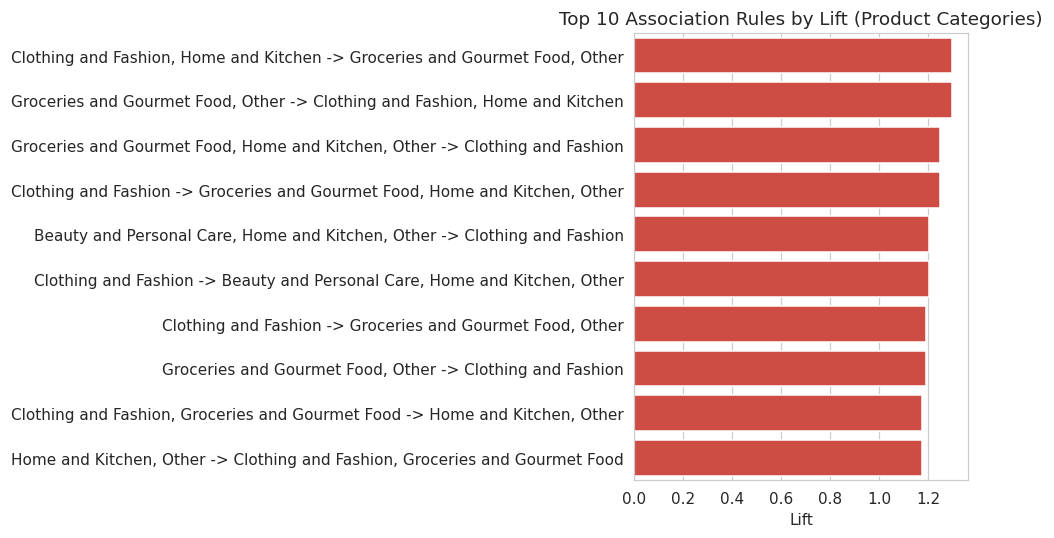

In [31]:
top_rules = rules.head(10).copy()
top_rules["rule"] = top_rules["antecedents_str"] + " -> " + top_rules["consequents_str"]

plt.figure(figsize=(9, 5))
sns.barplot(data=top_rules, x="lift", y="rule", color=COLORS[0])
plt.title("Top 10 Association Rules by Lift (Product Categories)")
plt.xlabel("Lift")
plt.ylabel("")
plt.tight_layout()
plt.show()


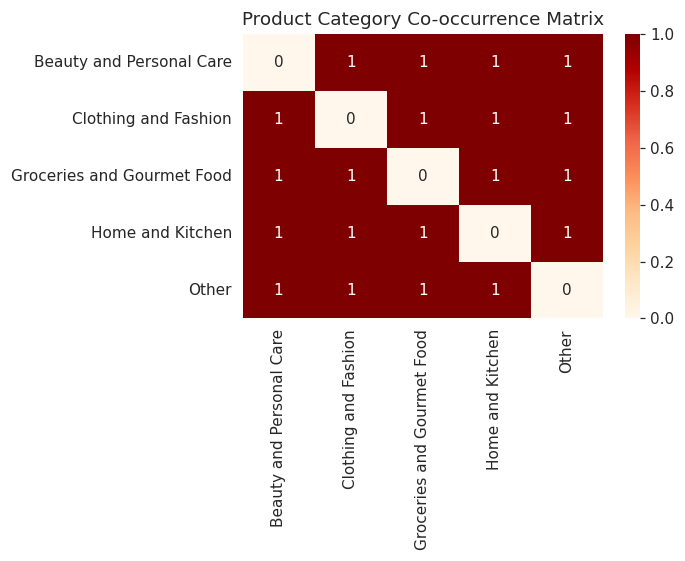

In [32]:
co_matrix = basket_df.T.dot(basket_df).astype(int)
vals = co_matrix.values.copy()
np.fill_diagonal(vals, 0)
co_matrix = pd.DataFrame(vals, index=co_matrix.index, columns=co_matrix.columns)

plt.figure(figsize=(6.5, 5.2))
sns.heatmap(co_matrix, annot=True, fmt="d", cmap="OrRd")
plt.title("Product Category Co-occurrence Matrix")
plt.tight_layout()
plt.show()


**Insight:** *Clothing and Fashion* is the strongest hub category, appearing as the
consequent in the highest-confidence rules (up to ~74% confidence when Groceries, Home &
Kitchen, and Other are already in the basket). This makes it the natural anchor for
cross-sell placements, bundle promotions, and "complete the basket" prompts at checkout.
Since price sensitivity is the #1 cart-abandonment factor (Section 2), pairing these bundles
with a modest discount or free-shipping threshold addresses both issues at once.

## 6. Key Takeaways

1. **Retention first.** 56% of customers are "At-Risk" on satisfaction/cart-completion
   grounds — prioritize win-back offers for this segment.
2. **Fix price & shipping friction.** These are the top two cart-abandonment drivers,
   ahead of anything related to app usability.
3. **Rebuild recommendations around basket affinity.** Helpfulness barely moves
   satisfaction today; use the *Clothing and Fashion*-anchored association rules instead of
   generic popularity logic.
4. **Segment by behavior, not demographics.** Age and gender don't differentiate segments;
   purchase frequency, cart completion, and satisfaction do.
5. **Invest in review quality signals** (verified purchase badges, helpful-vote counts)
   rather than review volume, since trust in reviews doesn't track with perceived rating
   accuracy.
